In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy import integrate
from pathlib import Path
import os
import glob
import constantes as c
from scipy.signal import find_peaks

class Señal:
    def __init__(self, file):
        self.tV, self.V, self.tI, self.I = self.csv(file)

    def csv(self, file):
        df = pd.read_csv(Path(file).expanduser(), index_col=0)
        t_volt, volt = [np.asarray(df[f'Tiempo CH{c.CH_VOLT}']), 
                        np.asarray(df[f'Voltaje CH{c.CH_VOLT}'])]
        t_istr, istr = [np.asarray(df[f'Tiempo CH{c.CH_ISTR}']), 
                1/c.R * np.asarray(df[f'Voltaje CH{c.CH_ISTR}'])]
        return t_volt, volt, t_istr, istr


class SeñalReff(Señal):
    def __init__(self, file):
        super().__init__(file)
        self.Vpp, self.Vpp_err, self.T, self.T_err = self.fit_sin()

    def fit_sin(self):
        def sin(x, A, T, p, B): return A*np.sin(2*np.pi/T*x + p) + B
        initialGuess = [7500, 1/8000, 0, 10000]
        popt, pcov = curve_fit(sin, self.tV, self.V, p0=initialGuess)
        perr = np.sqrt(np.diag(pcov))
        A, T, p, B = popt
        A_err, T_err, p_err, B_err = perr
        return 2*A, 2*A_err, T, T_err

class SeñalZoom(Señal):
    def __init__(self, file_zoom, T):
        super().__init__(file_zoom)
        self.t, self.I, self.V = self.filtro()
        self.P_avg = self.potencia(T)
        self.I_avg = self.corriente()

    def filtro(self):
        dt = 50
        # 0.005 np.max(self.I)/2
        #indices =  np.where(self.I > 0.005)[0]
        indices = find_peaks(self.I, distance=20)[0]
        i, f = indices[0] - dt, indices[-1] + dt
        plt.plot(self.tI, self.I)
        t_filtro, y = np.linspace([self.tI[i], np.mean(self.I[i-dt:i])], [self.tI[f], np.mean(self.I[f:f+dt])], f-i).T
        I_filtro = self.I[i:f] - y
        V_filtro = self.V[i:f]
        return t_filtro, I_filtro, V_filtro
    
    def potencia(self, T):
        return integrate.simpson(self.I * self.V, x=self.t) / T
    
    def corriente(self):
        return np.mean(self.I)
    
class SeñalProm:
    def __init__(self, folder):
        self.señalesReff, self.señalesZoom = self.data(folder)
        self.P_avg, self.P_std = self.potencia()
        self.V_vpp, self.V_std = self.voltaje()
        self.I_avg, self.I_std = self.corriente()

    def data(self, folder):
        files = glob.glob(os.path.join(c.ROOT, folder, '*.csv'))
        señalesReff = [SeñalReff(file) for file in files if 'reff' in os.path.basename(file)]
        señalesZoom = [SeñalZoom(file, señalesReff[0].T) for file in files if 'reff' not in os.path.basename(file)]
        return señalesReff, señalesZoom
    
    def potencia(self):
        P_avg = np.mean([señal.P_avg for señal in self.señalesZoom], axis=0)
        P_std = np.std([señal.P_avg for señal in self.señalesZoom], axis=0)
        return P_avg, P_std

    def voltaje(self):
        V_vpp = np.mean([señal.Vpp for señal in self.señalesReff], axis=0)
        V_std = np.mean([señal.Vpp_err for señal in self.señalesReff], axis=0)
        return V_vpp, V_std
    
    def corriente(self):
        I_avg = np.mean([señal.I_avg for señal in self.señalesZoom], axis=0)
        I_std = np.std([señal.I_avg for señal in self.señalesZoom], axis=0) # Dudas, ¿asi se calculaba el error del promedio de un promedio? Además, estamos con std de numpy que está sesgado
        return I_avg, I_std
    
    def __repr__(self):
        return f'''
                    I = {self.I_avg*1000:.2f} ± {self.I_std*1000:.2f} mA
                    V = {self.V_vpp/1000:.2f} ± {self.V_std/1000:.2f} kV
                    P = {self.P_avg:.2f} ± {self.P_std:.2f} W'''


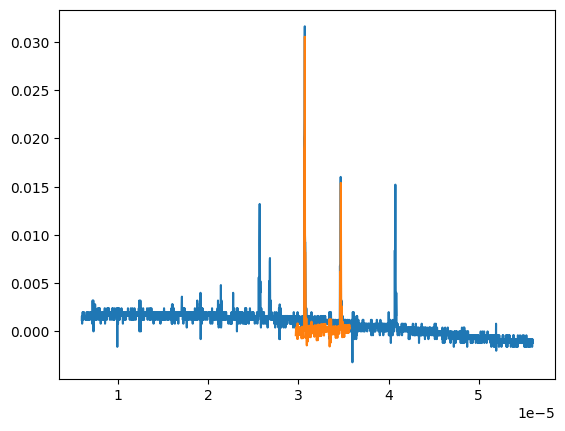

In [29]:
root = c.ROOT + '/04-06/tratamiento-e4/'
sr = SeñalReff(root + 'reff-tratamiento-e4 2024-06-04 17h 49m 35s.csv')
sz = SeñalZoom(root + 'tratamiento-e4 2024-06-04 17h 50m 42s.csv', sr.T)

plt.plot(sz.t, sz.I)

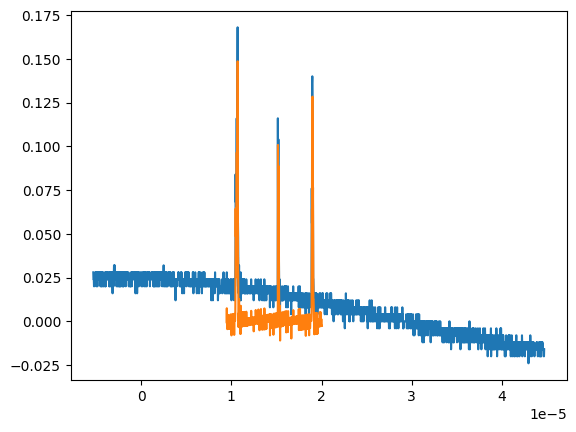

In [30]:
root = c.ROOT + '/05-07/tratamiento-e4-e6-vidrio/'
sr = SeñalReff(root + 'reff-e4-e6-vidrio 2024-07-05 08h 49m 21s.csv')
sz = SeñalZoom(root + 'e4-e6-vidrio 2024-07-05 08h 54m 32s.csv', sr.T)

plt.plot(sz.t, sz.I)


                    I = 5.17 ± 4.01 mA
                    V = 15.72 ± 0.01 kV
                    P = 5.24 ± 2.44 W

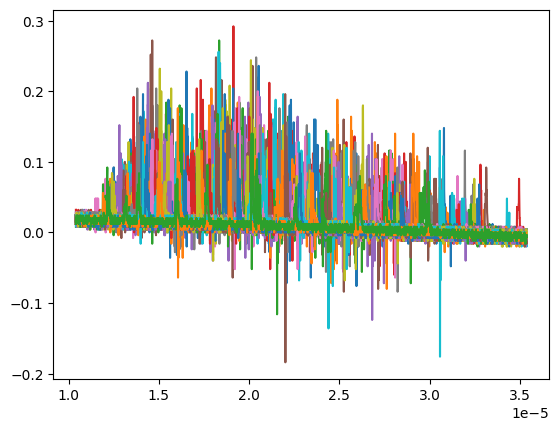

In [31]:
SeñalProm('05-07/tratamiento-e4-e6-vidrio/zoom')